# fxhash — most common JavaScript files across projects

For every downloaded project this notebook looks at which `.js` files it
contains and counts **how many projects include each file**. Libraries reused by
many artists (p5.js, three.js, ...) rise to the top.

Requires the `projects/` folder (created by `download_projects.py`).

In [1]:
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

PROJECTS = 'projects'

def scan_js():
    counts = Counter()
    n_projects = 0
    for root, _, files in os.walk(PROJECTS):
        if '_source.txt' not in files:
            continue
        n_projects += 1
        js_in_project = set()
        for r, _, fs in os.walk(root):
            if '__MACOSX' in r.split(os.sep):
                continue
            for f in fs:
                if f.lower().endswith('.js') and not f.startswith('._'):
                    js_in_project.add(f)
        counts.update(js_in_project)
    return n_projects, counts

n_projects, counts = scan_js()

df = (pd.Series(counts, name='projects')
        .sort_values(ascending=False)
        .rename_axis('js_file')
        .reset_index())
df['pct'] = (df['projects'] / n_projects * 100).round(1)
df.to_csv('data/js_file_counts.csv', index=False)

print(f'{n_projects} projects scanned, {len(df)} distinct .js file names')
df.head(15)

2761 projects scanned, 1948 distinct .js file names


,js_file,projects,pct
0,bundle.js,1089,39.4
1,sketch.js,902,32.7
2,p5.min.js,857,31.0
3,p5.js,606,21.9
4,index.js,436,15.8
5,p5.sound.min.js,271,9.8
6,script.js,136,4.9
7,fxhash.min.js,124,4.5
8,hydra-synth.js,111,4.0
9,fxhash.js,111,4.0


## Top 30 most common .js files

Linear scale, exact count on each bar.

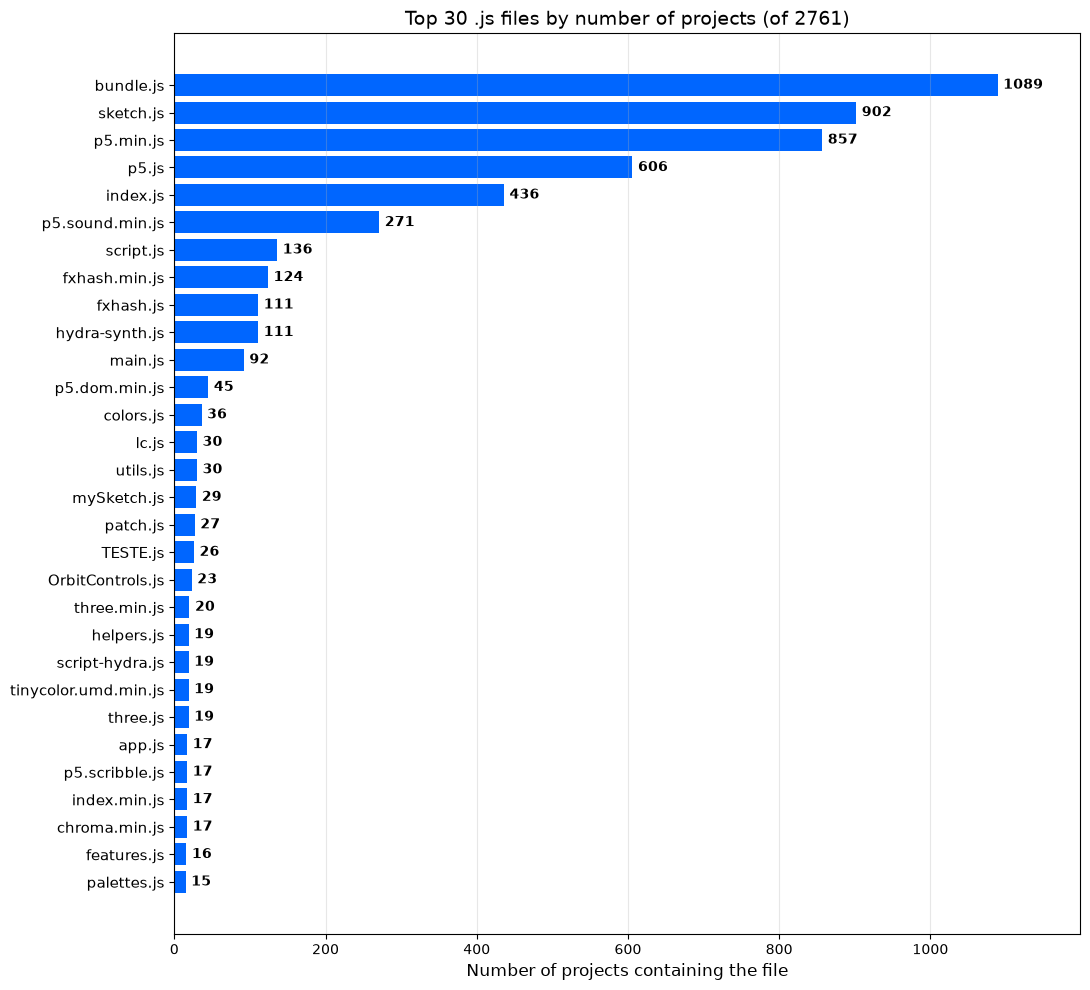

In [2]:
TOP = 30
top = df.head(TOP).sort_values('projects')

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(top['js_file'], top['projects'], color='#0066ff')
ax.bar_label(bars, padding=4, fontsize=10, fontweight='bold')
ax.set_title(f'Top {TOP} .js files by number of projects (of {n_projects})', fontsize=14)
ax.set_xlabel('Number of projects containing the file', fontsize=12)
ax.margins(x=0.1)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## All files shared by many projects

Every file used by at least **`MIN_PROJECTS`** projects (linear scale, exact
counts). Lower `MIN_PROJECTS` to include more files.

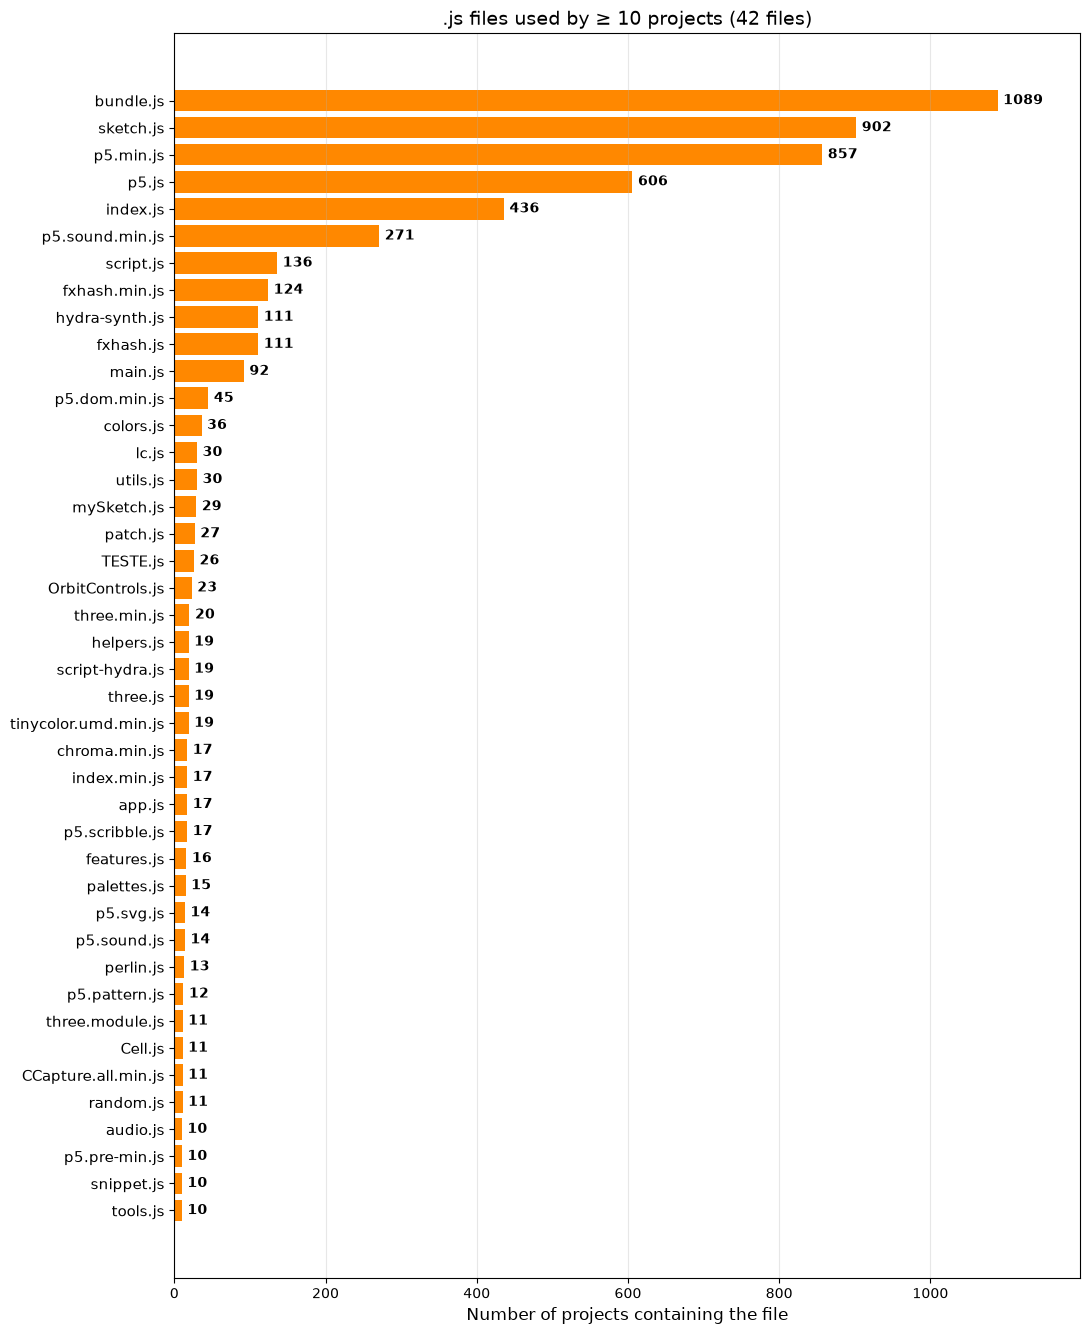

In [3]:
MIN_PROJECTS = 10
sub = df[df['projects'] >= MIN_PROJECTS].sort_values('projects')

fig, ax = plt.subplots(figsize=(11, max(6, len(sub) * 0.32)))
bars = ax.barh(sub['js_file'], sub['projects'], color='#ff8800')
ax.bar_label(bars, padding=4, fontsize=10, fontweight='bold')
ax.set_title(f'.js files used by \u2265 {MIN_PROJECTS} projects ({len(sub)} files)', fontsize=14)
ax.set_xlabel('Number of projects containing the file', fontsize=12)
ax.margins(x=0.1)
ax.tick_params(axis='y', labelsize=11)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()